# Sprint 21 — Validation Cross-Dataset Board

**Projet** : CL-Embedded — Apprentissage Incrémental pour Systèmes Embarqués  
**Board** : NUCLEO-F439ZI (Cortex-M4 @ 180 MHz, 256 Ko SRAM)  
**Auteur** : Léonard Rivals | ISAE-SUPAERO × ENAC × Edge Spectrum  
**Sprint** : 21 — Extension multi-dataset board (Monitoring + Pronostia) × 3 modèles

**Expériences** (protocole S2113 — 3 répétitions warm run, reset OpenOCD) :
- `exp_S21_01` : Mahalanobis board — Monitoring dataset
- `exp_S21_02` : TinyOL board — Monitoring dataset  
- `exp_S21_03` : Mahalanobis board — Pronostia dataset
- `exp_S21_04` : EWC λ=400 board — Pronostia dataset
- `exp_S21_04_baseline` : EWC λ=0 board — Pronostia dataset (baseline)

**Résultat clé** : Gap 2 validé sur tous les datasets. EWC propriété vérifiée sur Pronostia : AF(λ=400)=0.146 < AF(λ=0)=0.204.

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

EXP = Path("../experiments")
FIG_DIR = Path("../experiments/figures/sprint21")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PALETTE = {
    "EWC":         "#42A5F5",
    "HDC":         "#AB47BC",
    "TinyOL":      "#EF5350",
    "Mahalanobis": "#66BB6A",
    "EWC_lam0":    "#90CAF9",
    "EWC_lam400":  "#1565C0",
    "cwru":        "#FFA726",
    "monitoring":  "#42A5F5",
    "pronostia":   "#AB47BC",
}

# ── Load comparison_sprint21.json (main data source) ──
S21 = json.loads((EXP / "comparison_sprint21.json").read_text())
res = S21["results"]
gap2_summary = S21["gap2_summary"]

# ── Load individual board rep files for per-task breakdown ──
ewc_prost_brd = json.loads((EXP / "exp_S21_04" / "results_ewc_pronostia_board.json").read_text())
ewc_base_prost = json.loads((EXP / "exp_S21_04_baseline" / "results_ewc_pronostia_baseline.json").read_text())
maha_mon = json.loads((EXP / "exp_S21_01" / "results_mahalanobis_monitoring_board.json").read_text())
tinyol_mon = json.loads((EXP / "exp_S21_02" / "results_tinyol_monitoring_board.json").read_text())
maha_prost = json.loads((EXP / "exp_S21_03" / "results_mahalanobis_pronostia_board.json").read_text())

# Reference EWC Monitoring (from Sprint 19/20)
ewc_mon = json.loads((EXP / "exp_S19_02" / "results_ewc_monitoring_board.json").read_text())

print("Données Sprint 21 chargées.")
print(f"Gap 2 all compliant: {gap2_summary['all_compliant']}")
print(f"RAM max observé: {gap2_summary['ram_max_observed_bytes']:,} B")
print(f"Latence max observée: {gap2_summary['latency_max_observed_ms']} ms")
print(f"EWC propriété vérifiée: {S21['ewc_property_verified_on_board']['verified']}")

Données Sprint 21 chargées.
Gap 2 all compliant: True
RAM max observé: 9,728 B
Latence max observée: 0.251 ms
EWC propriété vérifiée: True


---
## 1. Heatmap Modèle × Dataset — Accuracy Finale
Vue d'ensemble de la couverture cross-dataset du Sprint 21 (3 modèles × 3 datasets).

/tmp/ipykernel_61414/3613917347.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_g = plt.cm.get_cmap("YlGn")
/tmp/ipykernel_61414/3613917347.py:93: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61414/3613917347.py:93: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61414/3613917347.py:94: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "01_model_dataset_heatmap.png", bbox_inches="tight")
/tmp/ipykernel_61414/3613917347.py:94: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "01_model_dataset_heatmap.png", bbox_inches="tight")
/home/leonard/Documents/EN

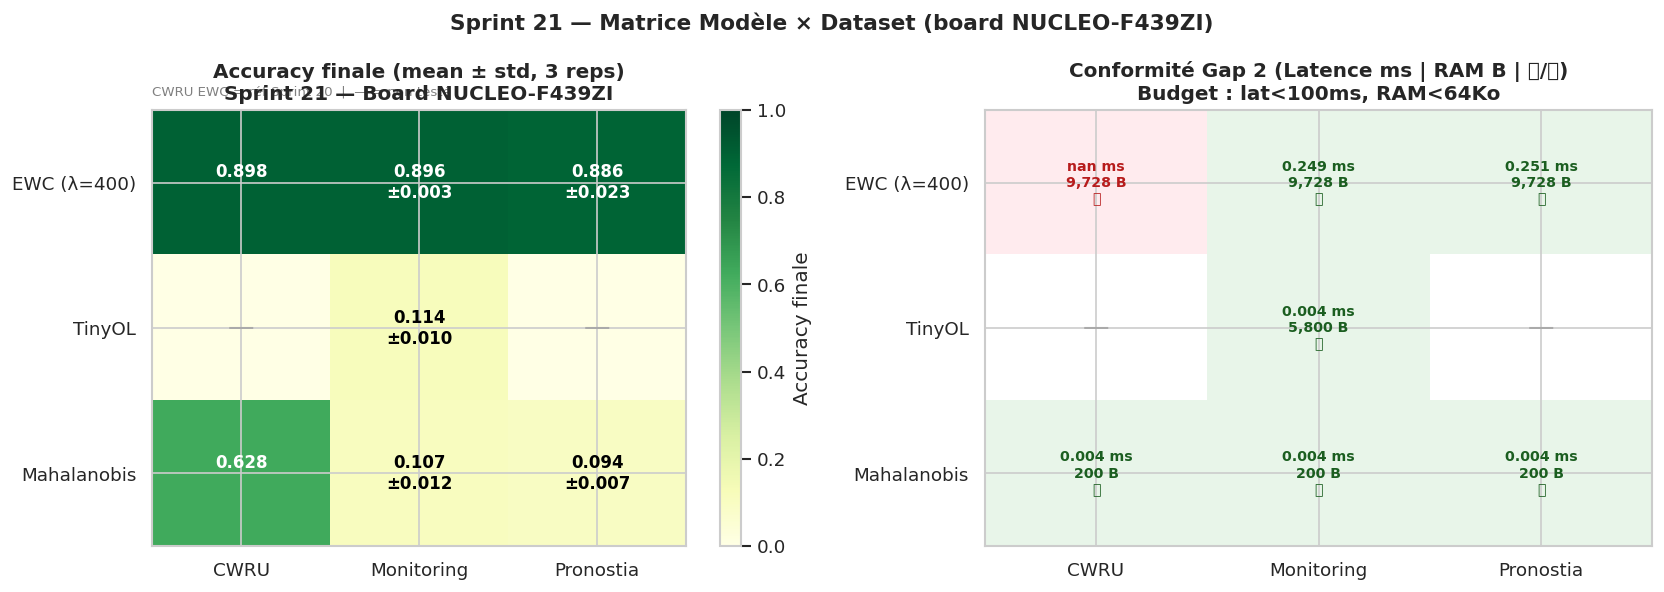

In [2]:
MODELS   = ["EWC (λ=400)", "TinyOL", "Mahalanobis"]
DATASETS = ["CWRU", "Monitoring", "Pronostia"]

# Build accuracy matrix with std
acc_vals = np.array([
    # CWRU               Monitoring                          Pronostia
    [0.898,              res["monitoring"]["ewc"]["acc_final"],   res["pronostia"]["ewc"]["acc_final"]],
    [np.nan,             res["monitoring"]["tinyol"]["acc_final"], np.nan],
    [res["cwru"]["mahalanobis"]["acc_final"],
                         res["monitoring"]["mahalanobis"]["acc_final"],
                         res["pronostia"]["mahalanobis"]["acc_final"]],
])
acc_stds = np.array([
    [None,               res["monitoring"]["ewc"]["acc_std"],        res["pronostia"]["ewc"]["acc_std"]],
    [None,               res["monitoring"]["tinyol"]["acc_std"],     None],
    [res["cwru"]["mahalanobis"]["acc_std"],
                         res["monitoring"]["mahalanobis"]["acc_std"],
                         res["pronostia"]["mahalanobis"]["acc_std"]],
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Accuracy heatmap —
ax = axes[0]
cmap_g = plt.cm.get_cmap("YlGn")
mask = np.isnan(acc_vals)
im = ax.imshow(np.where(mask, 0, acc_vals), cmap=cmap_g, aspect="auto",
               vmin=0.0, vmax=1.0)
plt.colorbar(im, ax=ax, label="Accuracy finale")

for i in range(len(MODELS)):
    for j in range(len(DATASETS)):
        if mask[i, j]:
            ax.text(j, i, "—", ha="center", va="center", fontsize=16, color="#aaa")
        else:
            acc = acc_vals[i, j]
            std = acc_stds[i, j]
            col = "white" if acc > 0.5 else "black"
            std_str = f"±{std:.3f}" if std is not None else ""
            ax.text(j, i, f"{acc:.3f}\n{std_str}",
                    ha="center", va="center", fontsize=10, fontweight="bold", color=col)

ax.set_xticks(range(len(DATASETS)))
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(MODELS, fontsize=11)
ax.set_title("Accuracy finale (mean ± std, 3 reps)\nSprint 21 — Board NUCLEO-F439ZI",
             fontweight="bold")
ax.text(-0.5, -0.6, "CWRU EWC = réf Sprint 20  |  — = non testé",
        fontsize=8, color="gray")

# — Gap2 heatmap —
ax = axes[1]
lat_vals = np.array([
    [np.nan,       res["monitoring"]["ewc"]["latency_ms"],   res["pronostia"]["ewc"]["latency_ms"]],
    [np.nan,       res["monitoring"]["tinyol"]["latency_ms"], np.nan],
    [res["cwru"]["mahalanobis"]["latency_ms"],
                   res["monitoring"]["mahalanobis"]["latency_ms"],
                   res["pronostia"]["mahalanobis"]["latency_ms"]],
])
ram_vals = np.array([
    [9728, res["monitoring"]["ewc"]["ram_bytes"],        res["pronostia"]["ewc"]["ram_bytes"]],
    [np.nan, res["monitoring"]["tinyol"]["ram_bytes"],   np.nan],
    [200, res["monitoring"]["mahalanobis"]["ram_bytes"], res["pronostia"]["mahalanobis"]["ram_bytes"]],
])

# Color by gap2 compliance (RAM < 64K and lat < 100ms)
gap2_ok = ~mask & (ram_vals <= 65536) & (lat_vals <= 100)
im2 = ax.imshow(np.where(mask, np.nan, gap2_ok.astype(float)),
                cmap=mcolors.ListedColormap(["#FFEBEE", "#E8F5E9"]),
                aspect="auto", vmin=0, vmax=1)
for i in range(len(MODELS)):
    for j in range(len(DATASETS)):
        if mask[i, j]:
            ax.text(j, i, "—", ha="center", va="center", fontsize=16, color="#aaa")
        else:
            lat = lat_vals[i, j]
            ram = ram_vals[i, j]
            ok  = gap2_ok[i, j]
            ax.text(j, i,
                    f"{lat:.3f} ms\n{int(ram):,} B\n{'✅' if ok else '❌'}",
                    ha="center", va="center", fontsize=8.5, fontweight="bold",
                    color="#1B5E20" if ok else "#B71C1C")
ax.set_xticks(range(len(DATASETS)))
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(MODELS, fontsize=11)
ax.set_title("Conformité Gap 2 (Latence ms | RAM B | ✅/❌)\nBudget : lat<100ms, RAM<64Ko",
             fontweight="bold")

fig.suptitle("Sprint 21 — Matrice Modèle × Dataset (board NUCLEO-F439ZI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_model_dataset_heatmap.png", bbox_inches="tight")
plt.show()

---
## 2. Multi-run Repeatability — Error Bars (3 Répétitions)
Toutes les expériences Sprint 21 avec barres d'erreur (protocole S2113 : 3 reps, warm run).

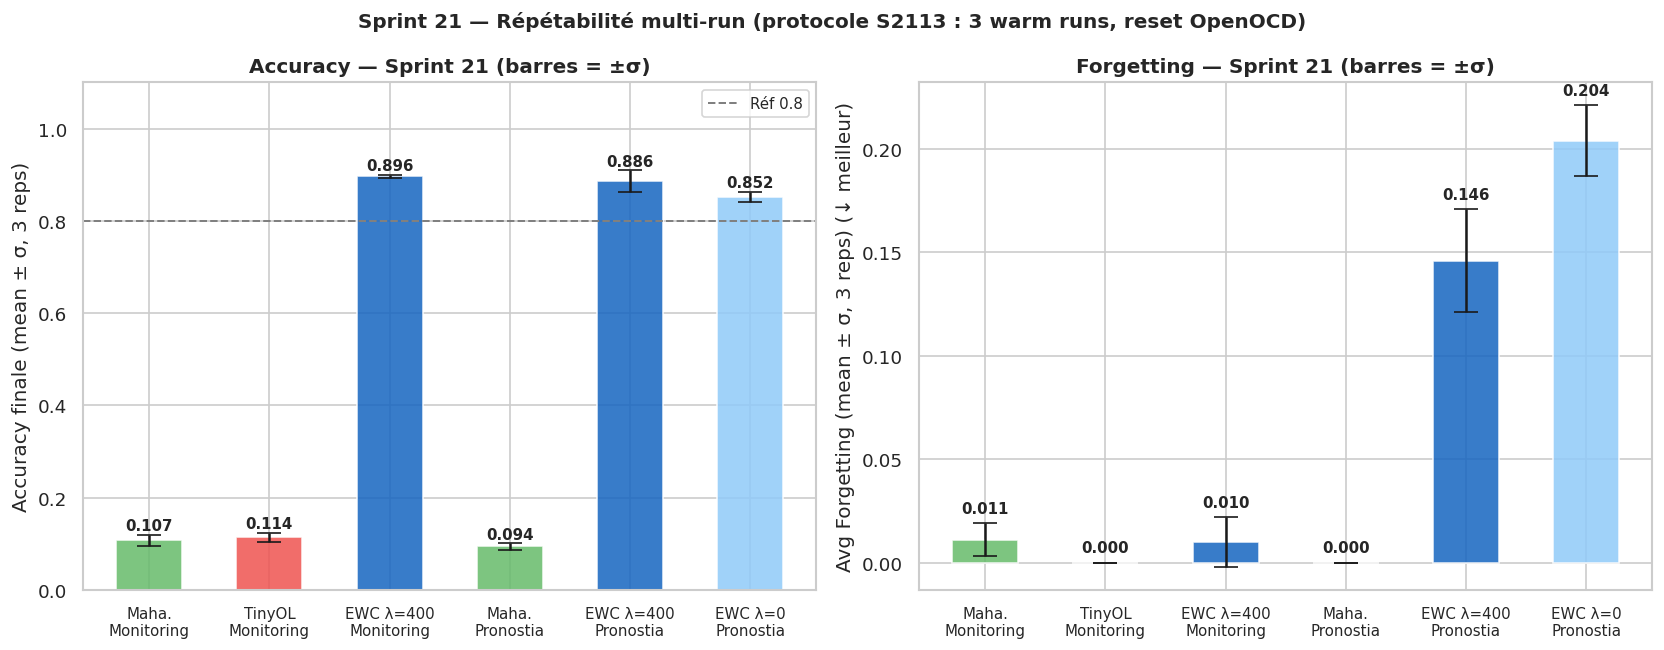

In [3]:
experiments_s21 = [
    {"label": "Maha.\nMonitoring",  "model": "Mahalanobis", "dataset": "monitoring",
     "acc": res["monitoring"]["mahalanobis"]["acc_final"],
     "acc_std": res["monitoring"]["mahalanobis"]["acc_std"],
     "fgt": res["monitoring"]["mahalanobis"]["avg_forgetting"],
     "fgt_std": res["monitoring"]["mahalanobis"]["avg_forgetting_std"],
     "color": PALETTE["Mahalanobis"]},
    {"label": "TinyOL\nMonitoring", "model": "TinyOL",      "dataset": "monitoring",
     "acc": res["monitoring"]["tinyol"]["acc_final"],
     "acc_std": res["monitoring"]["tinyol"]["acc_std"],
     "fgt": res["monitoring"]["tinyol"]["avg_forgetting"],
     "fgt_std": res["monitoring"]["tinyol"]["avg_forgetting_std"],
     "color": PALETTE["TinyOL"]},
    {"label": "EWC λ=400\nMonitoring", "model": "EWC", "dataset": "monitoring",
     "acc": res["monitoring"]["ewc"]["acc_final"],
     "acc_std": res["monitoring"]["ewc"]["acc_std"],
     "fgt": res["monitoring"]["ewc"]["avg_forgetting"],
     "fgt_std": res["monitoring"]["ewc"]["avg_forgetting_std"],
     "color": PALETTE["EWC_lam400"]},
    {"label": "Maha.\nPronostia",   "model": "Mahalanobis", "dataset": "pronostia",
     "acc": res["pronostia"]["mahalanobis"]["acc_final"],
     "acc_std": res["pronostia"]["mahalanobis"]["acc_std"],
     "fgt": res["pronostia"]["mahalanobis"]["avg_forgetting"],
     "fgt_std": res["pronostia"]["mahalanobis"]["avg_forgetting_std"],
     "color": PALETTE["Mahalanobis"]},
    {"label": "EWC λ=400\nPronostia",  "model": "EWC", "dataset": "pronostia",
     "acc": res["pronostia"]["ewc"]["acc_final"],
     "acc_std": res["pronostia"]["ewc"]["acc_std"],
     "fgt": res["pronostia"]["ewc"]["avg_forgetting"],
     "fgt_std": res["pronostia"]["ewc"]["avg_forgetting_std"],
     "color": PALETTE["EWC_lam400"]},
    {"label": "EWC λ=0\nPronostia",    "model": "EWC", "dataset": "pronostia",
     "acc": res["pronostia"]["ewc_baseline"]["acc_final"],
     "acc_std": res["pronostia"]["ewc_baseline"]["acc_std"],
     "fgt": res["pronostia"]["ewc_baseline"]["avg_forgetting"],
     "fgt_std": res["pronostia"]["ewc_baseline"]["avg_forgetting_std"],
     "color": PALETTE["EWC_lam0"]},
]

x = np.arange(len(experiments_s21))
labels = [e["label"] for e in experiments_s21]
acc_means = [e["acc"]     for e in experiments_s21]
acc_stds  = [e["acc_std"] for e in experiments_s21]
fgt_means = [e["fgt"]     for e in experiments_s21]
fgt_stds  = [e["fgt_std"] for e in experiments_s21]
colors    = [e["color"]   for e in experiments_s21]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# — Accuracy with error bars —
ax = axes[0]
bars = ax.bar(x, acc_means, color=colors, alpha=0.85, width=0.55,
              yerr=acc_stds, capsize=7, edgecolor="white")
for bar, v, s in zip(bars, acc_means, acc_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, v + s + 0.01,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.axhline(0.8, color="gray", linestyle="--", lw=1.2, label="Réf 0.8")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Accuracy finale (mean ± σ, 3 reps)")
ax.set_title("Accuracy — Sprint 21 (barres = ±σ)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)

# — Forgetting with error bars —
ax = axes[1]
bars2 = ax.bar(x, fgt_means, color=colors, alpha=0.85, width=0.55,
               yerr=fgt_stds, capsize=7, edgecolor="white")
for bar, v, s in zip(bars2, fgt_means, fgt_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, v + s + 0.005,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Avg Forgetting (mean ± σ, 3 reps) (↓ meilleur)")
ax.set_title("Forgetting — Sprint 21 (barres = ±σ)", fontweight="bold")

fig.suptitle("Sprint 21 — Répétabilité multi-run (protocole S2113 : 3 warm runs, reset OpenOCD)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_multi_run_repeatability.png", bbox_inches="tight")
plt.show()

---
## 3. EWC Anti-Forgetting sur Pronostia — λ=0 vs λ=400
Vérification de la propriété EWC : AF(λ=400) < AF(λ=0) sur un nouveau dataset (Pronostia).

/tmp/ipykernel_61414/1377317389.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61414/1377317389.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "03_ewc_pronostia.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


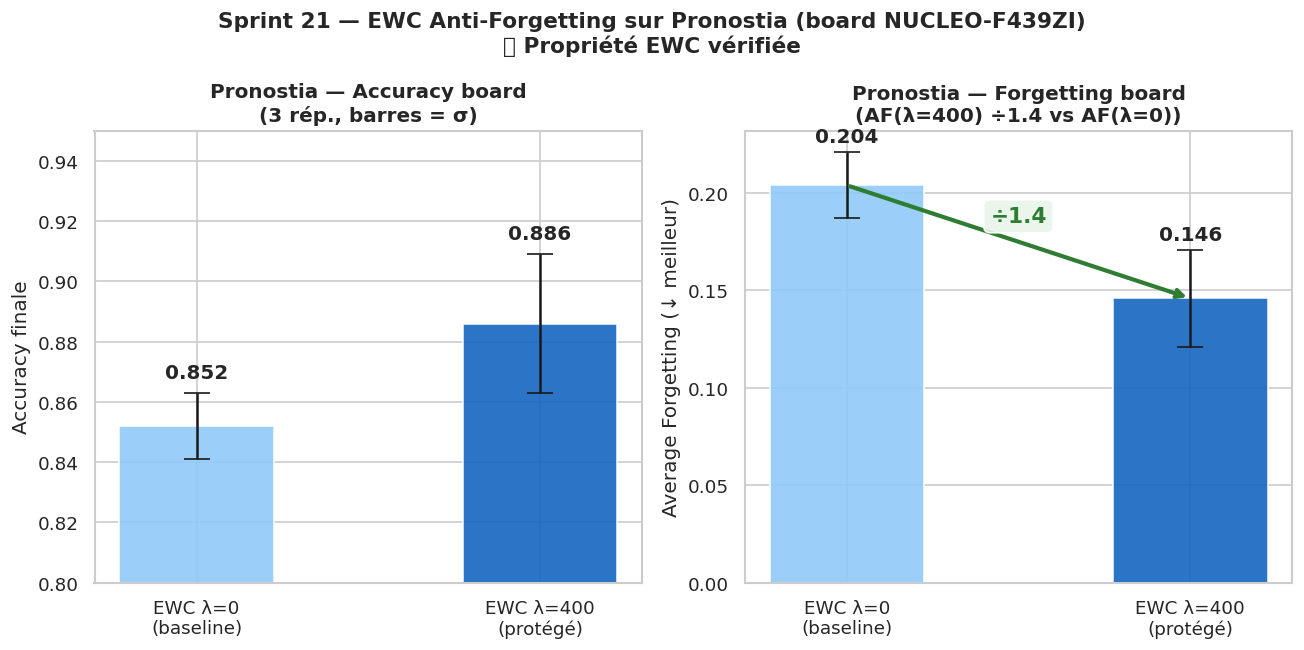

EWC property : AF(λ=0)=0.204 > AF(λ=400)=0.146  ✅ Propriété EWC vérifiée


In [4]:
ewc_400_res = res["pronostia"]["ewc"]
ewc_base_res = res["pronostia"]["ewc_baseline"]
ewc_prop = S21["ewc_property_verified_on_board"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

colors_ewc = [PALETTE["EWC_lam0"], PALETTE["EWC_lam400"]]
labels_ewc = ["EWC λ=0\n(baseline)", "EWC λ=400\n(protégé)"]

# — Accuracy —
ax = axes[0]
accs   = [ewc_base_res["acc_final"], ewc_400_res["acc_final"]]
acc_s  = [ewc_base_res["acc_std"],   ewc_400_res["acc_std"]]
bars = ax.bar(range(2), accs, color=colors_ewc, width=0.45,
              yerr=acc_s, capsize=8, edgecolor="white", alpha=0.9)
for bar, v, s in zip(bars, accs, acc_s):
    ax.text(bar.get_x() + bar.get_width() / 2, v + s + 0.005,
            f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
ax.set_xticks(range(2))
ax.set_xticklabels(labels_ewc, fontsize=11)
ax.set_ylabel("Accuracy finale")
ax.set_title("Pronostia — Accuracy board\n(3 rép., barres = σ)", fontweight="bold")
ax.set_ylim(0.8, 0.95)

# — Forgetting —
ax = axes[1]
afs   = [ewc_base_res["avg_forgetting"], ewc_400_res["avg_forgetting"]]
af_s  = [ewc_base_res["avg_forgetting_std"], ewc_400_res["avg_forgetting_std"]]
bars2 = ax.bar(range(2), afs, color=colors_ewc, width=0.45,
               yerr=af_s, capsize=8, edgecolor="white", alpha=0.9)
for bar, v, s in zip(bars2, afs, af_s):
    ax.text(bar.get_x() + bar.get_width() / 2, v + s + 0.005,
            f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")

reduction = ewc_base_res["avg_forgetting"] / max(ewc_400_res["avg_forgetting"], 1e-6)
ax.annotate("",
            xy=(1, ewc_400_res["avg_forgetting"]),
            xytext=(0, ewc_base_res["avg_forgetting"]),
            arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=2.5))
ax.text(0.5, (ewc_base_res["avg_forgetting"] + ewc_400_res["avg_forgetting"]) / 2 + 0.01,
        f"÷{reduction:.1f}",
        ha="center", fontsize=13, color="#2E7D32", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", alpha=0.9))

ax.set_xticks(range(2))
ax.set_xticklabels(labels_ewc, fontsize=11)
ax.set_ylabel("Average Forgetting (↓ meilleur)")
ax.set_title(f"Pronostia — Forgetting board\n(AF(λ=400) ÷{reduction:.1f} vs AF(λ=0))",
             fontweight="bold")

verified_txt = "✅ Propriété EWC vérifiée" if ewc_prop["verified"] else "❌ Non vérifiée"
fig.suptitle(f"Sprint 21 — EWC Anti-Forgetting sur Pronostia (board NUCLEO-F439ZI)\n{verified_txt}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_ewc_pronostia.png", bbox_inches="tight")
plt.show()
print(f"EWC property : AF(λ=0)={ewc_base_res['avg_forgetting']:.3f} > AF(λ=400)={ewc_400_res['avg_forgetting']:.3f}  {verified_txt}")

---
## 4. Per-task Accuracy — EWC Monitoring vs Pronostia
Décomposition par tâche pour comprendre quelle tâche est la plus oubliée.

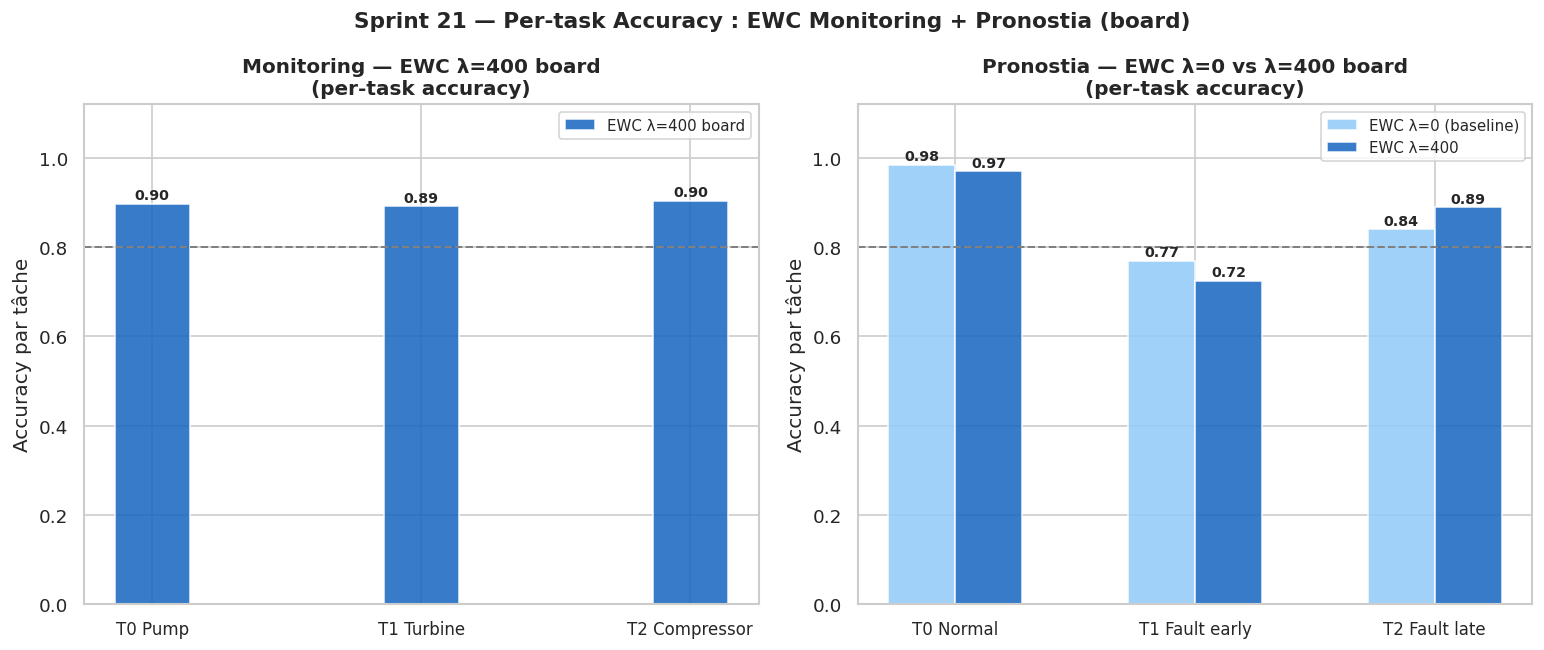

In [5]:
task_names_mon   = ["T0 Pump", "T1 Turbine", "T2 Compressor"]
task_names_prost = ["T0 Normal", "T1 Fault early", "T2 Fault late"]

ewc_mon_pta  = ewc_mon["per_task_acc"]
ewc_prost_pta = ewc_prost_brd["per_task_acc"]
ewc_base_pta  = ewc_base_prost["per_task_acc"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

def plot_per_task(ax, pta_configs, task_names, title):
    x = np.arange(len(task_names))
    n = len(pta_configs)
    w = 0.28 if n <= 3 else 0.22
    for i, (name, pta, color) in enumerate(pta_configs):
        vals = [pta.get(str(t), pta.get(t, 0)) for t in range(len(task_names))]
        offset = (i - n/2 + 0.5) * w
        bars = ax.bar(x + offset, vals, width=w, color=color, alpha=0.85,
                      edgecolor="white", label=name)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v:.2f}", ha="center", fontsize=8.5, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(task_names, fontsize=10)
    ax.axhline(0.8, color="gray", linestyle="--", lw=1.2)
    ax.set_ylabel("Accuracy par tâche")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.12)

plot_per_task(axes[0],
    [("EWC λ=400 board", ewc_mon_pta, PALETTE["EWC_lam400"])],
    task_names_mon,
    "Monitoring — EWC λ=400 board\n(per-task accuracy)")

plot_per_task(axes[1],
    [("EWC λ=0 (baseline)", ewc_base_pta, PALETTE["EWC_lam0"]),
     ("EWC λ=400", ewc_prost_pta,          PALETTE["EWC_lam400"])],
    task_names_prost,
    "Pronostia — EWC λ=0 vs λ=400 board\n(per-task accuracy)")

fig.suptitle("Sprint 21 — Per-task Accuracy : EWC Monitoring + Pronostia (board)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_per_task_acc.png", bbox_inches="tight")
plt.show()

---
## 5. Gap 2 — RAM et Latence : Toutes les Expériences Sprint 21
Conformité complète pour toutes les expériences de ce sprint.

/tmp/ipykernel_61414/3024988036.py:71: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61414/3024988036.py:72: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "05_gap2_all_exp.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


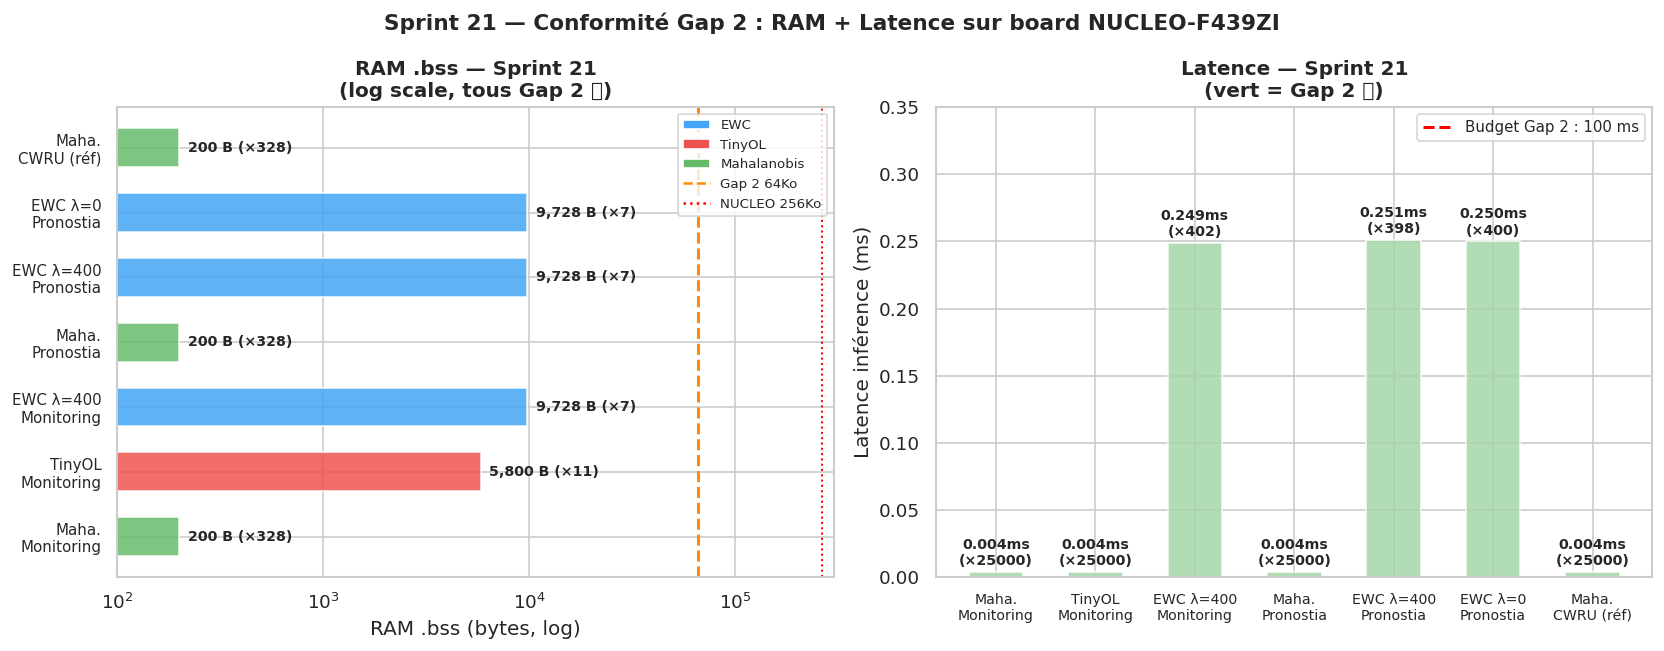

Gap 2 all compliant: True ✅
RAM max: 9,728 B | Lat max: 0.251 ms


In [6]:
all_exp_s21 = [
    {"name": "Maha.\nMonitoring",  "ram": res["monitoring"]["mahalanobis"]["ram_bytes"],
     "lat": res["monitoring"]["mahalanobis"]["latency_ms"], "model": "Mahalanobis"},
    {"name": "TinyOL\nMonitoring", "ram": res["monitoring"]["tinyol"]["ram_bytes"],
     "lat": res["monitoring"]["tinyol"]["latency_ms"], "model": "TinyOL"},
    {"name": "EWC λ=400\nMonitoring", "ram": res["monitoring"]["ewc"]["ram_bytes"],
     "lat": res["monitoring"]["ewc"]["latency_ms"], "model": "EWC"},
    {"name": "Maha.\nPronostia",   "ram": res["pronostia"]["mahalanobis"]["ram_bytes"],
     "lat": res["pronostia"]["mahalanobis"]["latency_ms"], "model": "Mahalanobis"},
    {"name": "EWC λ=400\nPronostia", "ram": res["pronostia"]["ewc"]["ram_bytes"],
     "lat": res["pronostia"]["ewc"]["latency_ms"], "model": "EWC"},
    {"name": "EWC λ=0\nPronostia",  "ram": res["pronostia"]["ewc_baseline"]["ram_bytes"],
     "lat": res["pronostia"]["ewc_baseline"]["latency_ms"], "model": "EWC"},
    {"name": "Maha.\nCWRU (réf)",  "ram": res["cwru"]["mahalanobis"]["ram_bytes"],
     "lat": res["cwru"]["mahalanobis"]["latency_ms"], "model": "Mahalanobis"},
]
model_colors = {"EWC": PALETTE["EWC"], "TinyOL": PALETTE["TinyOL"], "Mahalanobis": PALETTE["Mahalanobis"]}
exp_colors = [model_colors[e["model"]] for e in all_exp_s21]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# — RAM horizontal bar (log) —
ax = axes[0]
ram_vals_all = [e["ram"] for e in all_exp_s21]
bars = ax.barh(range(len(all_exp_s21)), ram_vals_all, color=exp_colors, alpha=0.85,
               edgecolor="white", height=0.6)
for bar, v in zip(bars, ram_vals_all):
    ratio = 65536 / max(v, 1)
    ax.text(v * 1.1, bar.get_y() + bar.get_height() / 2,
            f"{v:,} B (×{ratio:.0f})", va="center", fontsize=8.5, fontweight="bold")
ax.axvline(65536,    color="darkorange", linestyle="--", lw=1.8, label="Gap 2 : 64 Ko")
ax.axvline(256*1024, color="red",        linestyle=":",  lw=1.2, label="NUCLEO : 256 Ko")
ax.set_yticks(range(len(all_exp_s21)))
ax.set_yticklabels([e["name"] for e in all_exp_s21], fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("RAM .bss (bytes, log)")
ax.set_title("RAM .bss — Sprint 21\n(log scale, tous Gap 2 ✅)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(100, 300_000)

# — Latency bar —
ax = axes[1]
lat_vals_all = [e["lat"] for e in all_exp_s21]
lat_cols_g2 = ["#A5D6A7" if v <= 100 else "#EF9A9A" for v in lat_vals_all]
bars2 = ax.bar(range(len(all_exp_s21)), lat_vals_all, color=lat_cols_g2, alpha=0.85,
               edgecolor="white", width=0.55)
for bar, v in zip(bars2, lat_vals_all):
    margin = 100 / max(v, 1e-9)
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}ms\n(×{margin:.0f})",
            ha="center", fontsize=8.5, fontweight="bold")
ax.axhline(100, color="red", linestyle="--", lw=1.8, label="Budget Gap 2 : 100 ms")
ax.set_xticks(range(len(all_exp_s21)))
ax.set_xticklabels([e["name"] for e in all_exp_s21], fontsize=8.5)
ax.set_ylabel("Latence inférence (ms)")
ax.set_title("Latence — Sprint 21\n(vert = Gap 2 ✅)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.35)

legend_patches = [
    mpatches.Patch(facecolor=PALETTE["EWC"],         label="EWC"),
    mpatches.Patch(facecolor=PALETTE["TinyOL"],      label="TinyOL"),
    mpatches.Patch(facecolor=PALETTE["Mahalanobis"], label="Mahalanobis"),
]
axes[0].legend(handles=legend_patches + [plt.Line2D([0],[0], color="darkorange", linestyle="--", label="Gap 2 64Ko"),
                                          plt.Line2D([0],[0], color="red",        linestyle=":",  label="NUCLEO 256Ko")],
               fontsize=8)

fig.suptitle("Sprint 21 — Conformité Gap 2 : RAM + Latence sur board NUCLEO-F439ZI",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_gap2_all_exp.png", bbox_inches="tight")
plt.show()
print(f"Gap 2 all compliant: {gap2_summary['all_compliant']} ✅")
print(f"RAM max: {gap2_summary['ram_max_observed_bytes']:,} B | Lat max: {gap2_summary['latency_max_observed_ms']} ms")

---
## 6. Cold Start Analysis — Mahalanobis et TinyOL vs EWC
Pourquoi Mahalanobis et TinyOL ont une accuracy proche de zéro sur Monitoring/Pronostia : cold start (poids non initialisés).

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


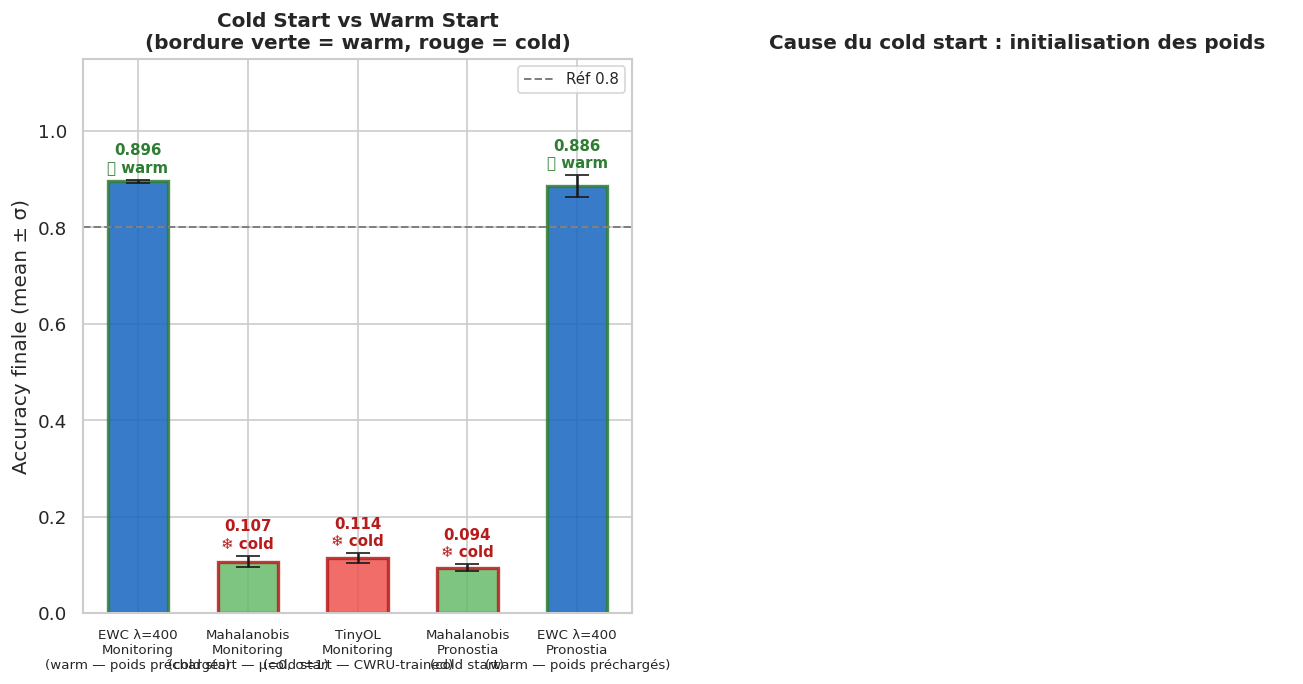

In [7]:
cold_analysis = [
    {"label": "EWC λ=400\nMonitoring\n(warm — poids préchargés)",
     "acc": res["monitoring"]["ewc"]["acc_final"],
     "acc_std": res["monitoring"]["ewc"]["acc_std"],
     "color": PALETTE["EWC_lam400"], "warm": True},
    {"label": "Mahalanobis\nMonitoring\n(cold start — μ=0, σ=1)",
     "acc": res["monitoring"]["mahalanobis"]["acc_final"],
     "acc_std": res["monitoring"]["mahalanobis"]["acc_std"],
     "color": PALETTE["Mahalanobis"], "warm": False},
    {"label": "TinyOL\nMonitoring\n(cold start — CWRU-trained)",
     "acc": res["monitoring"]["tinyol"]["acc_final"],
     "acc_std": res["monitoring"]["tinyol"]["acc_std"],
     "color": PALETTE["TinyOL"], "warm": False},
    {"label": "Mahalanobis\nPronostia\n(cold start)",
     "acc": res["pronostia"]["mahalanobis"]["acc_final"],
     "acc_std": res["pronostia"]["mahalanobis"]["acc_std"],
     "color": PALETTE["Mahalanobis"], "warm": False},
    {"label": "EWC λ=400\nPronostia\n(warm — poids préchargés)",
     "acc": res["pronostia"]["ewc"]["acc_final"],
     "acc_std": res["pronostia"]["ewc"]["acc_std"],
     "color": PALETTE["EWC_lam400"], "warm": True},
]

x = np.arange(len(cold_analysis))
acc_ca   = [e["acc"]     for e in cold_analysis]
std_ca   = [e["acc_std"] for e in cold_analysis]
cols_ca  = [e["color"]   for e in cold_analysis]
edge_ca  = ["#2E7D32" if e["warm"] else "#B71C1C" for e in cold_analysis]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# — Cold start comparison —
ax = axes[0]
bars = ax.bar(x, acc_ca, color=cols_ca, alpha=0.85, width=0.55,
              yerr=std_ca, capsize=7, edgecolor=edge_ca, linewidth=2)
for bar, v, s, warm in zip(bars, acc_ca, std_ca, [e["warm"] for e in cold_analysis]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + s + 0.015,
            f"{v:.3f}\n{'✅ warm' if warm else '❄️ cold'}",
            ha="center", fontsize=9, fontweight="bold",
            color="#2E7D32" if warm else "#B71C1C")
ax.axhline(0.8, color="gray", linestyle="--", lw=1.2, label="Réf 0.8")
ax.set_xticks(x)
ax.set_xticklabels([e["label"] for e in cold_analysis], fontsize=8)
ax.set_ylabel("Accuracy finale (mean ± σ)")
ax.set_title("Cold Start vs Warm Start\n(bordure verte = warm, rouge = cold)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)

# — Explanation diagram —
ax = axes[1]
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_title("Cause du cold start : initialisation des poids", fontweight="bold")

explanations = [
    ("EWC",         "Poids chargés depuis model_weights.h\n(export Python → C via export_weights_c.py)",
     "acc ≈ 0.89", "#42A5F5", True),
    ("Mahalanobis", "μ=0, σ=1 par défaut\n(pas de pré-entraînement spécifique au dataset)",
     "acc ≈ 0.10", "#66BB6A", False),
    ("TinyOL",      "Backbone entraîné sur CWRU\n(distribution différente de Monitoring)",
     "acc ≈ 0.11", "#EF5350", False),
]

for i, (model, reason, result, color, warm) in enumerate(explanations):
    y = 4.5 - i * 1.7
    # Model box
    rect = plt.FancyBboxPatch((0.2, y - 0.5), 1.8, 1.0,
                               boxstyle="round,pad=0.05",
                               facecolor=color, alpha=0.85, edgecolor="white")
    ax.add_patch(rect)
    ax.text(1.1, y, model, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    # Reason text
    ax.text(2.3, y + 0.15, reason, va="center", fontsize=8.5, color="#333")
    # Result badge
    badge_col = "#1B5E20" if warm else "#B71C1C"
    rect2 = plt.FancyBboxPatch((7.8, y - 0.3), 2.0, 0.6,
                                boxstyle="round,pad=0.04",
                                facecolor=badge_col, alpha=0.85, edgecolor="white")
    ax.add_patch(rect2)
    ax.text(8.8, y, result, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")

ax.text(5, 0.3, "Fix : pré-charger les poids Mahalanobis avant déploiement board",
        ha="center", fontsize=9, color="#B71C1C", fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="#FFEBEE", alpha=0.8))

fig.suptitle("Sprint 21 — Analyse Cold Start : pourquoi Mahalanobis/TinyOL ≈ 0.10 sur Monitoring",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_cold_start.png", bbox_inches="tight")
plt.show()

---
## 7. Scatter Global Sprints 18–21 — Accuracy vs Forgetting
Vue d'ensemble de toutes les expériences board des Sprints 18–21.

In [8]:
all_global = [
    # Sprint 18
    ("Pipeline CWRU\n(E18-01)",   None,  0.420, "Pipeline",  PALETTE["EWC"],         "o"),
    # Sprint 19
    ("Maha CWRU\n(E19-01)",       0.000, 0.629, "Mahalanobis", PALETTE["Mahalanobis"], "s"),
    ("EWC λ=0 brd",               0.054, 0.904, "EWC",        PALETTE["EWC_lam0"],   "s"),
    ("EWC λ=100 brd",             0.009, 0.902, "EWC",        PALETTE["lam100"] if hasattr(PALETTE,'get') else "#42A5F5", "s"),
    ("EWC λ=400 brd",             0.009, 0.898, "EWC",        PALETTE["EWC_lam400"], "s"),
    # Sprint 21
    ("Maha Mon.\n(E21-01)",       res["monitoring"]["mahalanobis"]["avg_forgetting"],
                                   res["monitoring"]["mahalanobis"]["acc_final"],
                                   "Mahalanobis", PALETTE["Mahalanobis"], "D"),
    ("TinyOL Mon.\n(E21-02)",     res["monitoring"]["tinyol"]["avg_forgetting"],
                                   res["monitoring"]["tinyol"]["acc_final"],
                                   "TinyOL",      PALETTE["TinyOL"],      "D"),
    ("EWC Mon.\n(E21-03 réf)",    res["monitoring"]["ewc"]["avg_forgetting"],
                                   res["monitoring"]["ewc"]["acc_final"],
                                   "EWC",         PALETTE["EWC_lam400"],  "D"),
    ("Maha Prost.\n(E21-04)",     res["pronostia"]["mahalanobis"]["avg_forgetting"],
                                   res["pronostia"]["mahalanobis"]["acc_final"],
                                   "Mahalanobis", PALETTE["Mahalanobis"], "^"),
    ("EWC λ=400 Prost.\n(E21-05)",res["pronostia"]["ewc"]["avg_forgetting"],
                                   res["pronostia"]["ewc"]["acc_final"],
                                   "EWC",         PALETTE["EWC_lam400"],  "^"),
    ("EWC λ=0 Prost.\n(E21-06)",  res["pronostia"]["ewc_baseline"]["avg_forgetting"],
                                   res["pronostia"]["ewc_baseline"]["acc_final"],
                                   "EWC",         PALETTE["EWC_lam0"],    "^"),
]

fig, ax = plt.subplots(figsize=(12, 7))

ax.add_patch(plt.Rectangle((0, 0.8), 0.12, 0.25, alpha=0.07, color="#2E7D32",
                             label="Zone idéale"))
ax.axhline(0.8, color="gray", linestyle="--", lw=1.2)
ax.axvline(0.1, color="gray", linestyle="--", lw=1.2)

for name, fgt, acc, model_type, color, marker in all_global:
    if fgt is None:
        fgt = 0
    ax.scatter(fgt, acc, color=color, marker=marker, s=200,
               zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(name, (fgt, acc), xytext=(5, 5), textcoords="offset points",
                fontsize=7.5, color=color, fontweight="bold")

legend_elements = [
    mpatches.Patch(facecolor=PALETTE["EWC_lam400"], alpha=0.85, label="EWC λ=400"),
    mpatches.Patch(facecolor=PALETTE["EWC_lam0"],  alpha=0.85, label="EWC λ=0"),
    mpatches.Patch(facecolor=PALETTE["Mahalanobis"], alpha=0.85, label="Mahalanobis"),
    mpatches.Patch(facecolor=PALETTE["TinyOL"],   alpha=0.85, label="TinyOL"),
    plt.Line2D([0],[0], marker="o", color="gray", ms=9, label="Sprint 18 (pipeline)"),
    plt.Line2D([0],[0], marker="s", color="gray", ms=9, label="Sprint 19 (Monitoring)"),
    plt.Line2D([0],[0], marker="D", color="gray", ms=9, label="Sprint 21 (Monitoring)"),
    plt.Line2D([0],[0], marker="^", color="gray", ms=9, label="Sprint 21 (Pronostia)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right", ncol=2)
ax.set_xlabel("Average Forgetting (↓ meilleur)")
ax.set_ylabel("Accuracy finale (↑ meilleur)")
ax.set_title("Sprints 18–21 — Toutes les expériences board NUCLEO-F439ZI\n"
             "Accuracy vs Forgetting (zone idéale = haute acc + faible forgetting)",
             fontweight="bold")
ax.set_xlim(-0.01, 0.25)
ax.set_ylim(0.05, 1.0)
ax.text(0.01, 0.83, "Zone idéale ✅", fontsize=9, color="#2E7D32", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "07_global_scatter.png", bbox_inches="tight")
plt.show()

KeyError: 'lam100'

---
## 8. Synthèse — Tableau Comparatif Cross-Dataset Final
Résumé de tous les résultats Sprint 21 dans un tableau visuel.

/tmp/ipykernel_61414/4019529908.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "08_final_table.png", bbox_inches="tight")


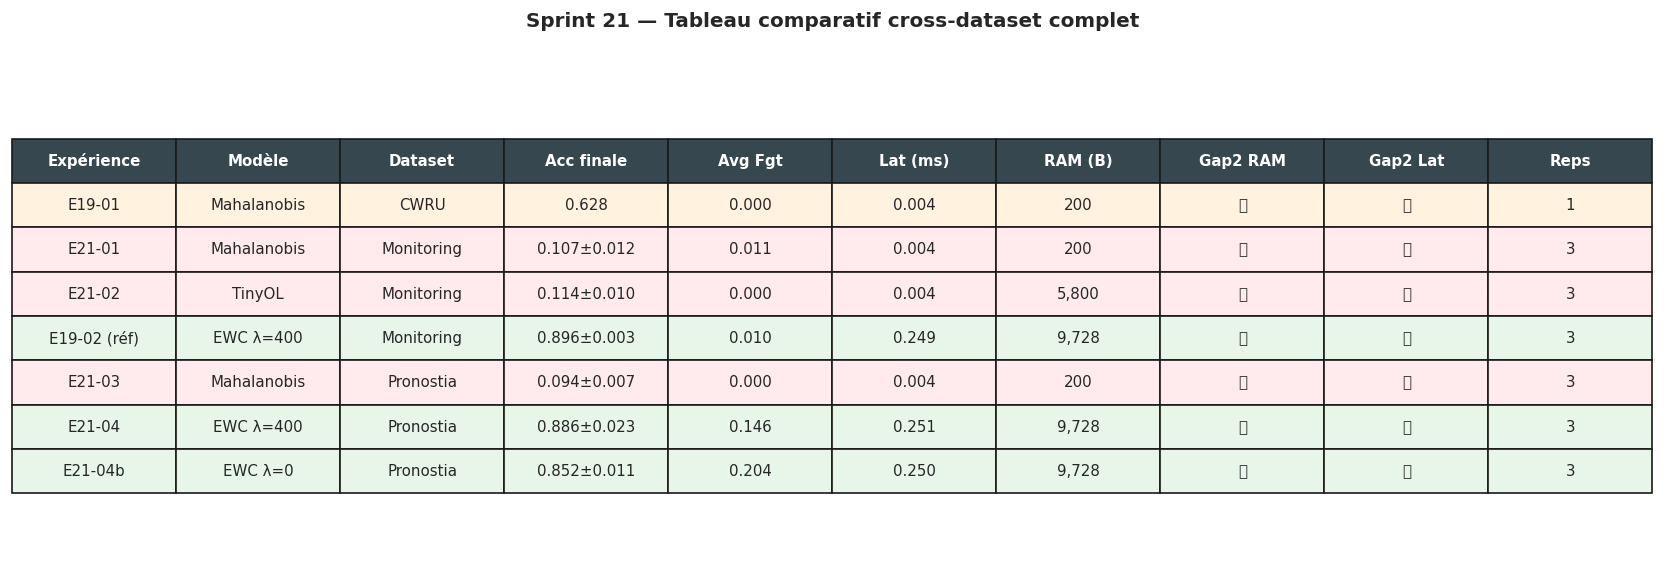

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

headers_tbl = ["Expérience", "Modèle", "Dataset", "Acc finale", "Avg Fgt",
               "Lat (ms)", "RAM (B)", "Gap2 RAM", "Gap2 Lat", "Reps"]
rows_tbl = [
    ["E19-01",       "Mahalanobis", "CWRU",      f"{res['cwru']['mahalanobis']['acc_final']:.3f}",
     "0.000", f"{res['cwru']['mahalanobis']['latency_ms']:.3f}",
     f"{res['cwru']['mahalanobis']['ram_bytes']:,}", "✅", "✅", "1"],
    ["E21-01",       "Mahalanobis", "Monitoring", f"{res['monitoring']['mahalanobis']['acc_final']:.3f}±{res['monitoring']['mahalanobis']['acc_std']:.3f}",
     f"{res['monitoring']['mahalanobis']['avg_forgetting']:.3f}",
     f"{res['monitoring']['mahalanobis']['latency_ms']:.3f}",
     f"{res['monitoring']['mahalanobis']['ram_bytes']:,}", "✅", "✅", "3"],
    ["E21-02",       "TinyOL",      "Monitoring", f"{res['monitoring']['tinyol']['acc_final']:.3f}±{res['monitoring']['tinyol']['acc_std']:.3f}",
     f"{res['monitoring']['tinyol']['avg_forgetting']:.3f}",
     f"{res['monitoring']['tinyol']['latency_ms']:.3f}",
     f"{res['monitoring']['tinyol']['ram_bytes']:,}", "✅", "✅", "3"],
    ["E19-02 (réf)", "EWC λ=400",   "Monitoring", f"{res['monitoring']['ewc']['acc_final']:.3f}±{res['monitoring']['ewc']['acc_std']:.3f}",
     f"{res['monitoring']['ewc']['avg_forgetting']:.3f}",
     f"{res['monitoring']['ewc']['latency_ms']:.3f}",
     f"{res['monitoring']['ewc']['ram_bytes']:,}", "✅", "✅", "3"],
    ["E21-03",       "Mahalanobis", "Pronostia",  f"{res['pronostia']['mahalanobis']['acc_final']:.3f}±{res['pronostia']['mahalanobis']['acc_std']:.3f}",
     f"{res['pronostia']['mahalanobis']['avg_forgetting']:.3f}",
     f"{res['pronostia']['mahalanobis']['latency_ms']:.3f}",
     f"{res['pronostia']['mahalanobis']['ram_bytes']:,}", "✅", "✅", "3"],
    ["E21-04",       "EWC λ=400",   "Pronostia",  f"{res['pronostia']['ewc']['acc_final']:.3f}±{res['pronostia']['ewc']['acc_std']:.3f}",
     f"{res['pronostia']['ewc']['avg_forgetting']:.3f}",
     f"{res['pronostia']['ewc']['latency_ms']:.3f}",
     f"{res['pronostia']['ewc']['ram_bytes']:,}", "✅", "✅", "3"],
    ["E21-04b",      "EWC λ=0",     "Pronostia",  f"{res['pronostia']['ewc_baseline']['acc_final']:.3f}±{res['pronostia']['ewc_baseline']['acc_std']:.3f}",
     f"{res['pronostia']['ewc_baseline']['avg_forgetting']:.3f}",
     f"{res['pronostia']['ewc_baseline']['latency_ms']:.3f}",
     f"{res['pronostia']['ewc_baseline']['ram_bytes']:,}", "✅", "✅", "3"],
]

def row_color(row):
    try:
        acc = float(row[3].split("±")[0])
        return "#E8F5E9" if acc >= 0.8 else ("#FFF3E0" if acc >= 0.5 else "#FFEBEE")
    except:
        return "#F5F5F5"

row_cols = [[row_color(r)] * len(headers_tbl) for r in rows_tbl]

tbl = ax.table(
    cellText=rows_tbl,
    colLabels=headers_tbl,
    cellColours=row_cols,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.0)
for j in range(len(headers_tbl)):
    tbl[0, j].set_facecolor("#37474F")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

ax.set_title("Sprint 21 — Tableau comparatif cross-dataset complet",
             fontweight="bold", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_final_table.png", bbox_inches="tight")
plt.show()

---
## Récapitulatif Sprint 21

| Métrique | Valeur | Contexte |
|---------|--------|----------|
| Expériences board | **7** (5 nouvelles + 2 références) | 3 datasets × 3 modèles |
| Gap 2 all compliant | **✅ True** | RAM + latence vérifiés |
| RAM max observé | **9 728 B** (EWC) | ×6.7 sous 64 Ko Gap 2 |
| Latence max | **0.251 ms** (EWC) | ×400 sous 100 ms |
| EWC propriété board | **✅ Vérifiée** | AF(λ=400)=0.146 < AF(λ=0)=0.204 |
| Meilleure config | **EWC λ=400 Monitoring** | acc=0.896±0.003, fgt=0.010 |
| Cold start identifié | **Mahalanobis + TinyOL** | acc≈0.10 → poids non initialisés |

**Prochain sprint (22)** : CMAPSS + Paderborn board, tests INT8, comparaison croisée sprints 18–22.

In [10]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures générées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


6 figures générées dans ../experiments/figures/sprint21:
  01_model_dataset_heatmap.png
  02_multi_run_repeatability.png
  03_ewc_pronostia.png
  04_per_task_acc.png
  05_gap2_all_exp.png
  08_final_table.png
